In [3]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel

In [4]:
DATA_FILE = Path("out/dcit_courses_skills.jsonl")

df = pd.read_json(DATA_FILE, lines=True)

df_expanded = df.explode("thematic_areas").rename(
    columns={"thematic_areas": "thematic_area"}
)

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(s).strip().replace(" ", "_") for s in skills if str(s).strip()]

df_expanded["skills"] = df_expanded["skills"].apply(normalize_multiword_skills)

cs_df = df_expanded[df_expanded["thematic_area"] == "computer_science"].copy()
it_df = df_expanded[df_expanded["thematic_area"] == "information_technology"].copy()

def clean_tokens(tokens):
    return [t for t in tokens if t not in {"computer_science", "information_technology"}]

cs_texts = [clean_tokens(t) for t in cs_df["skills"].tolist()]
it_texts = [clean_tokens(t) for t in it_df["skills"].tolist()]

In [5]:
def train_lda(texts, num_topics, label, no_below=1, no_above=0.8):
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(doc) for doc in texts]

    print(f"[{label}] Training LDA with k={num_topics}...")
    print(f"  Documents : {len(texts)}")
    print(f"  Vocab size: {len(dictionary)}")

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100,
    )

    print(f"\n[{label}] Top 10 words per topic:")
    for topic_num, topic_words in model.print_topics(num_words=10):
        print(f"  Topic {topic_num}: {topic_words}")

    return model, dictionary, corpus


def plot_top_words(model, num_topics, label, top_n=10):
    fig, axes = plt.subplots(
        (num_topics + 1) // 2, 2,
        figsize=(14, num_topics * 1.8),
        constrained_layout=True,
    )
    axes = axes.flatten()

    for topic_idx in range(num_topics):
        top_words = model.show_topic(topic_idx, topn=top_n)
        words = [w for w, _ in top_words]
        probs = [p for _, p in top_words]
        axes[topic_idx].barh(words[::-1], probs[::-1])
        axes[topic_idx].set_title(f"Topic {topic_idx}", fontsize=10)
        axes[topic_idx].tick_params(axis="y", labelsize=8)

    for idx in range(num_topics, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f"{label} — Course LDA Topics (k={num_topics})", fontsize=13)
    plt.show()

[Computer Science] Training LDA with k=14...
  Documents : 37
  Vocab size: 491

[Computer Science] Top 10 words per topic:
  Topic 0: 0.024*"programming_concept" + 0.024*"data_structure" + 0.024*"linear_search" + 0.024*"text_file" + 0.024*"priority_queue" + 0.024*"search_algorithm" + 0.024*"time_complexity" + 0.024*"binary_file" + 0.024*"software_system" + 0.024*"random_number_generation"
  Topic 1: 0.032*"problem_solve" + 0.025*"software_system" + 0.019*"project_management" + 0.019*"system_software" + 0.013*"software_design" + 0.013*"software_quality" + 0.013*"software_development" + 0.013*"system_testing" + 0.013*"verification_and_validation" + 0.013*"user_story"
  Topic 2: 0.024*"case" + 0.024*"access_control" + 0.013*"share_memory" + 0.013*"operating_system" + 0.013*"client_server_model" + 0.013*"mac_os" + 0.013*"mac_os_x" + 0.013*"memory_system" + 0.013*"computer_network" + 0.013*"kernel_mode"
  Topic 3: 0.025*"intelligent_system" + 0.013*"problem_solve" + 0.013*"decision_theory"

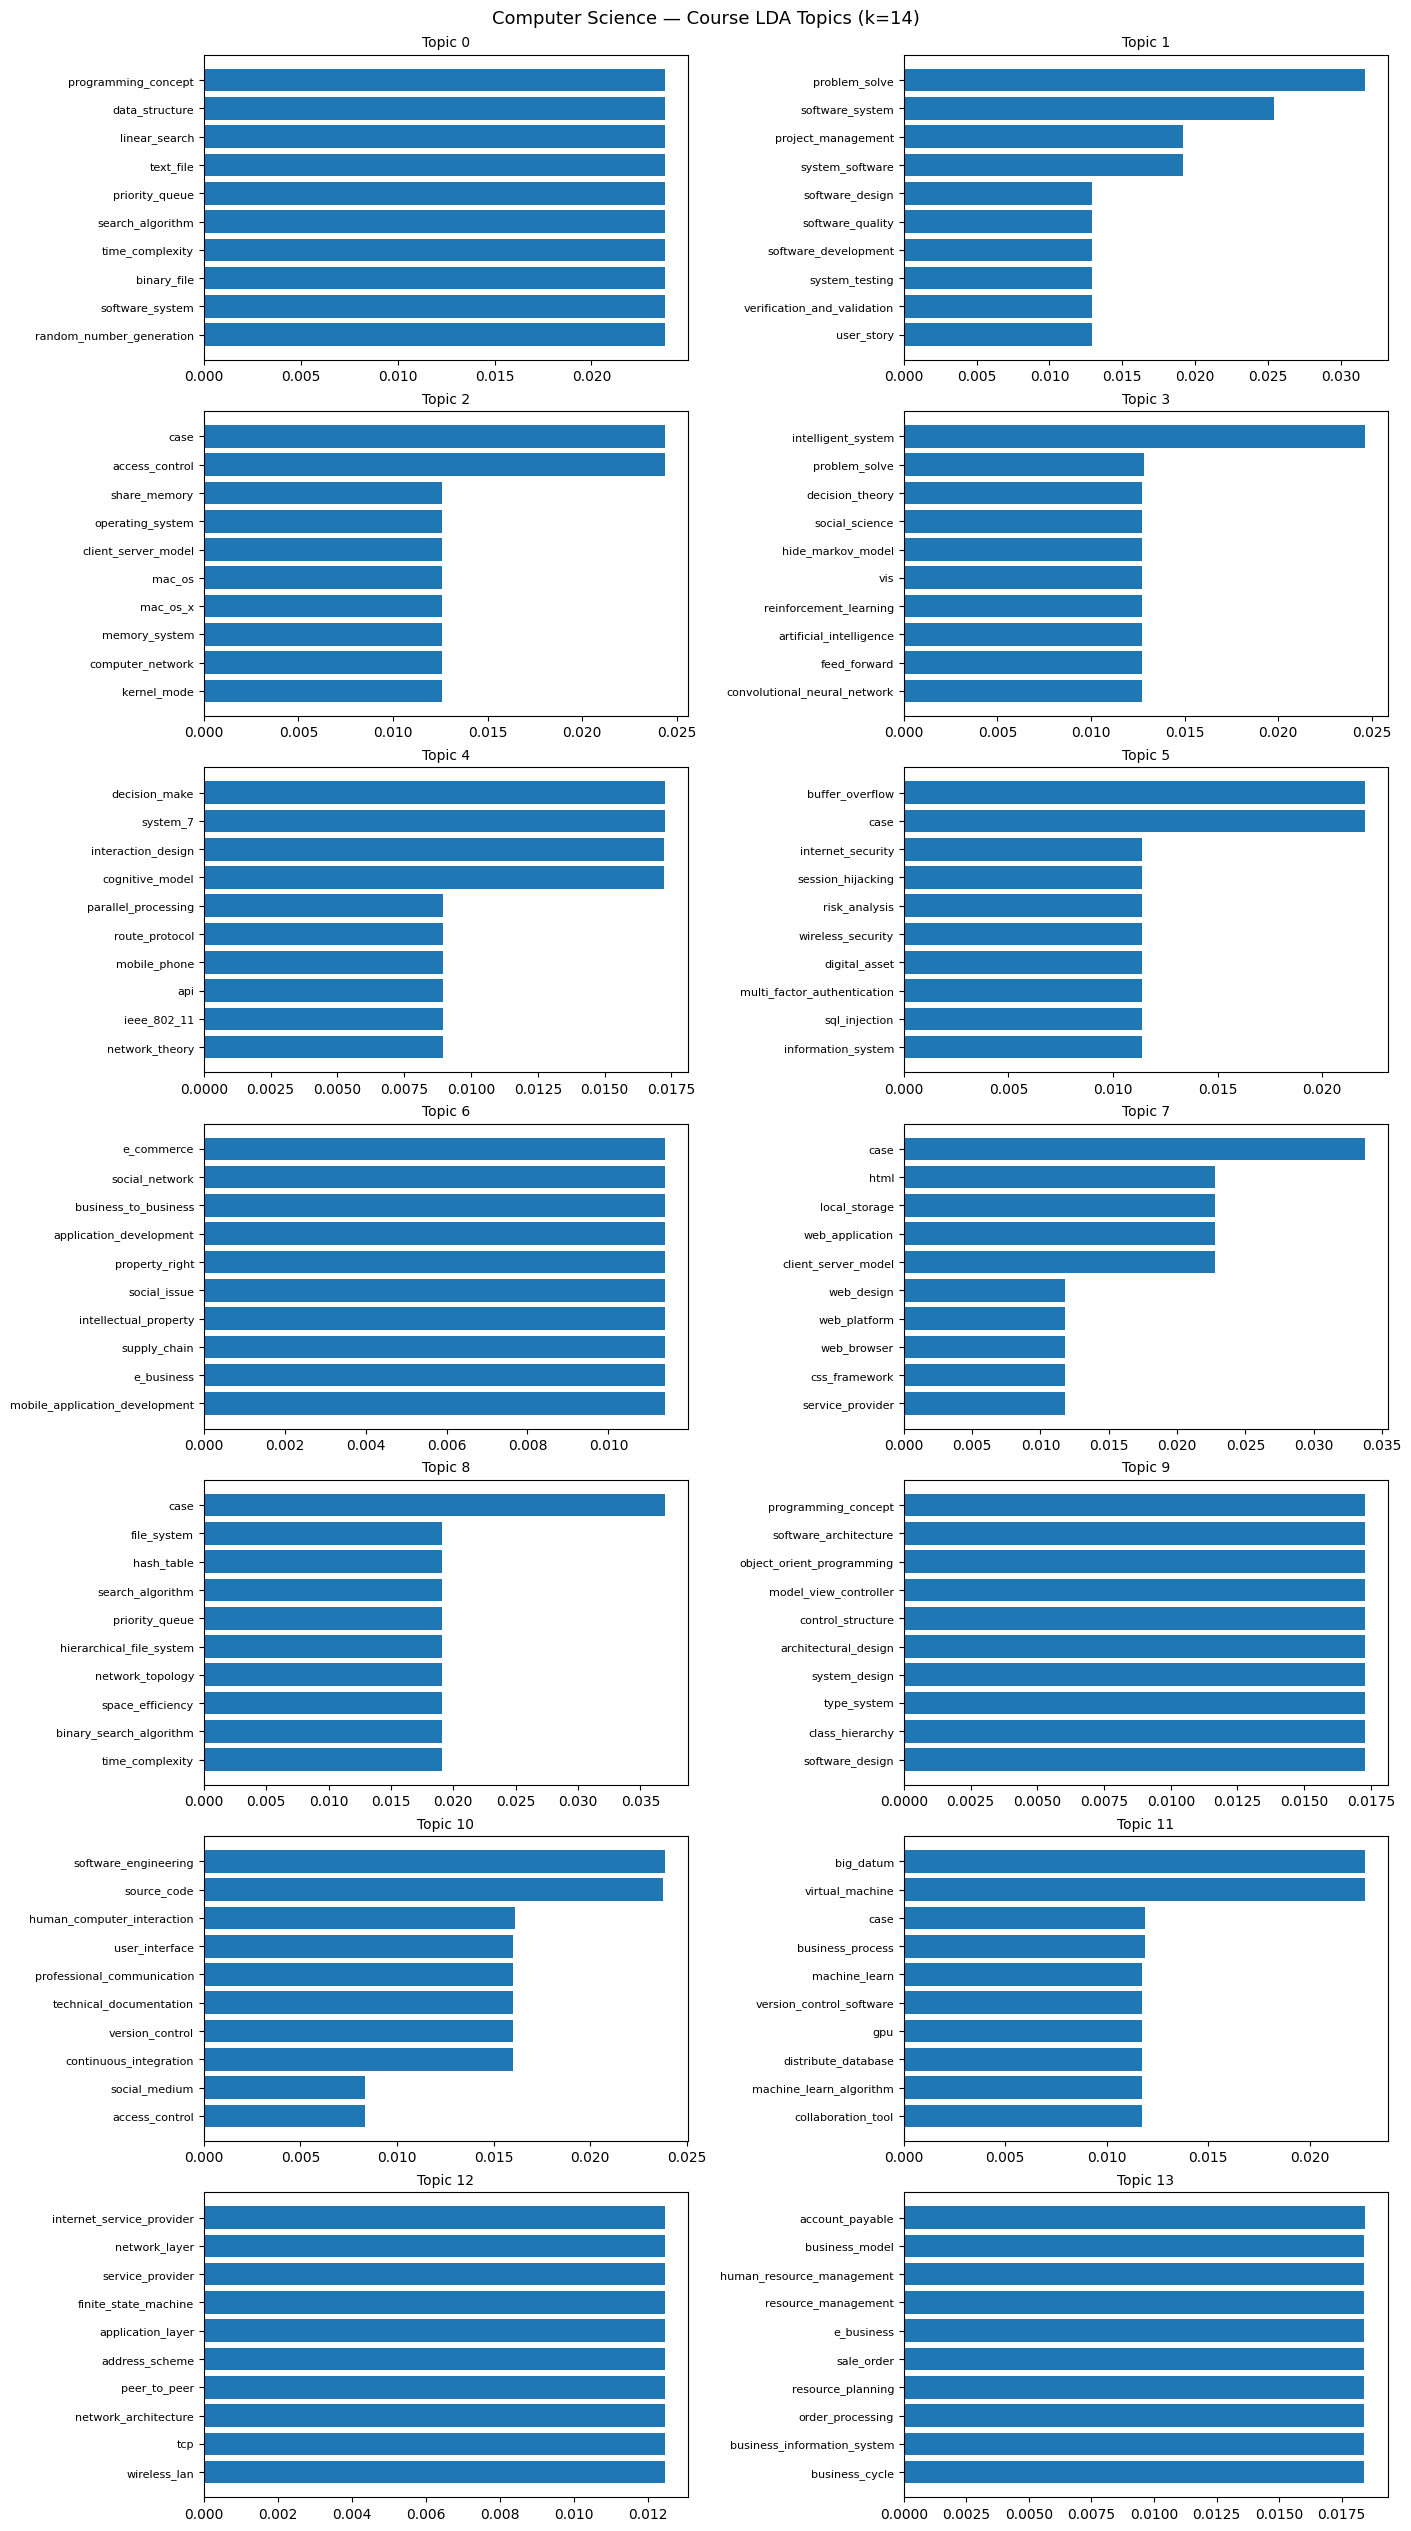

In [6]:
cs_model, cs_dictionary, cs_corpus = train_lda(cs_texts, 14, "Computer Science")
plot_top_words(cs_model, 14, "Computer Science")

[Information Technology] Training LDA with k=15...
  Documents : 31
  Vocab size: 439

[Information Technology] Top 10 words per topic:
  Topic 0: 0.021*"ui_pattern" + 0.021*"style_sheet" + 0.021*"local_storage" + 0.021*"link_table" + 0.021*"web_development" + 0.021*"web_browser" + 0.021*"application_programming_interface" + 0.021*"css" + 0.021*"css_framework" + 0.021*"web_application"
  Topic 1: 0.019*"system_design" + 0.019*"programming_environment" + 0.019*"user_interface" + 0.010*"programming_concept" + 0.010*"divide_and_conquer" + 0.010*"file_system" + 0.010*"operating_system" + 0.010*"virtual_machine" + 0.010*"machine_learn_algorithm" + 0.010*"unify_communication"
  Topic 2: 0.016*"business_system" + 0.016*"requirement_elicitation" + 0.016*"process_model" + 0.016*"software_design" + 0.016*"project_proposal" + 0.016*"information_management" + 0.016*"cocomo" + 0.016*"unit_testing" + 0.016*"cost_estimation" + 0.016*"development_management"
  Topic 3: 0.017*"social_network" + 0.009*"

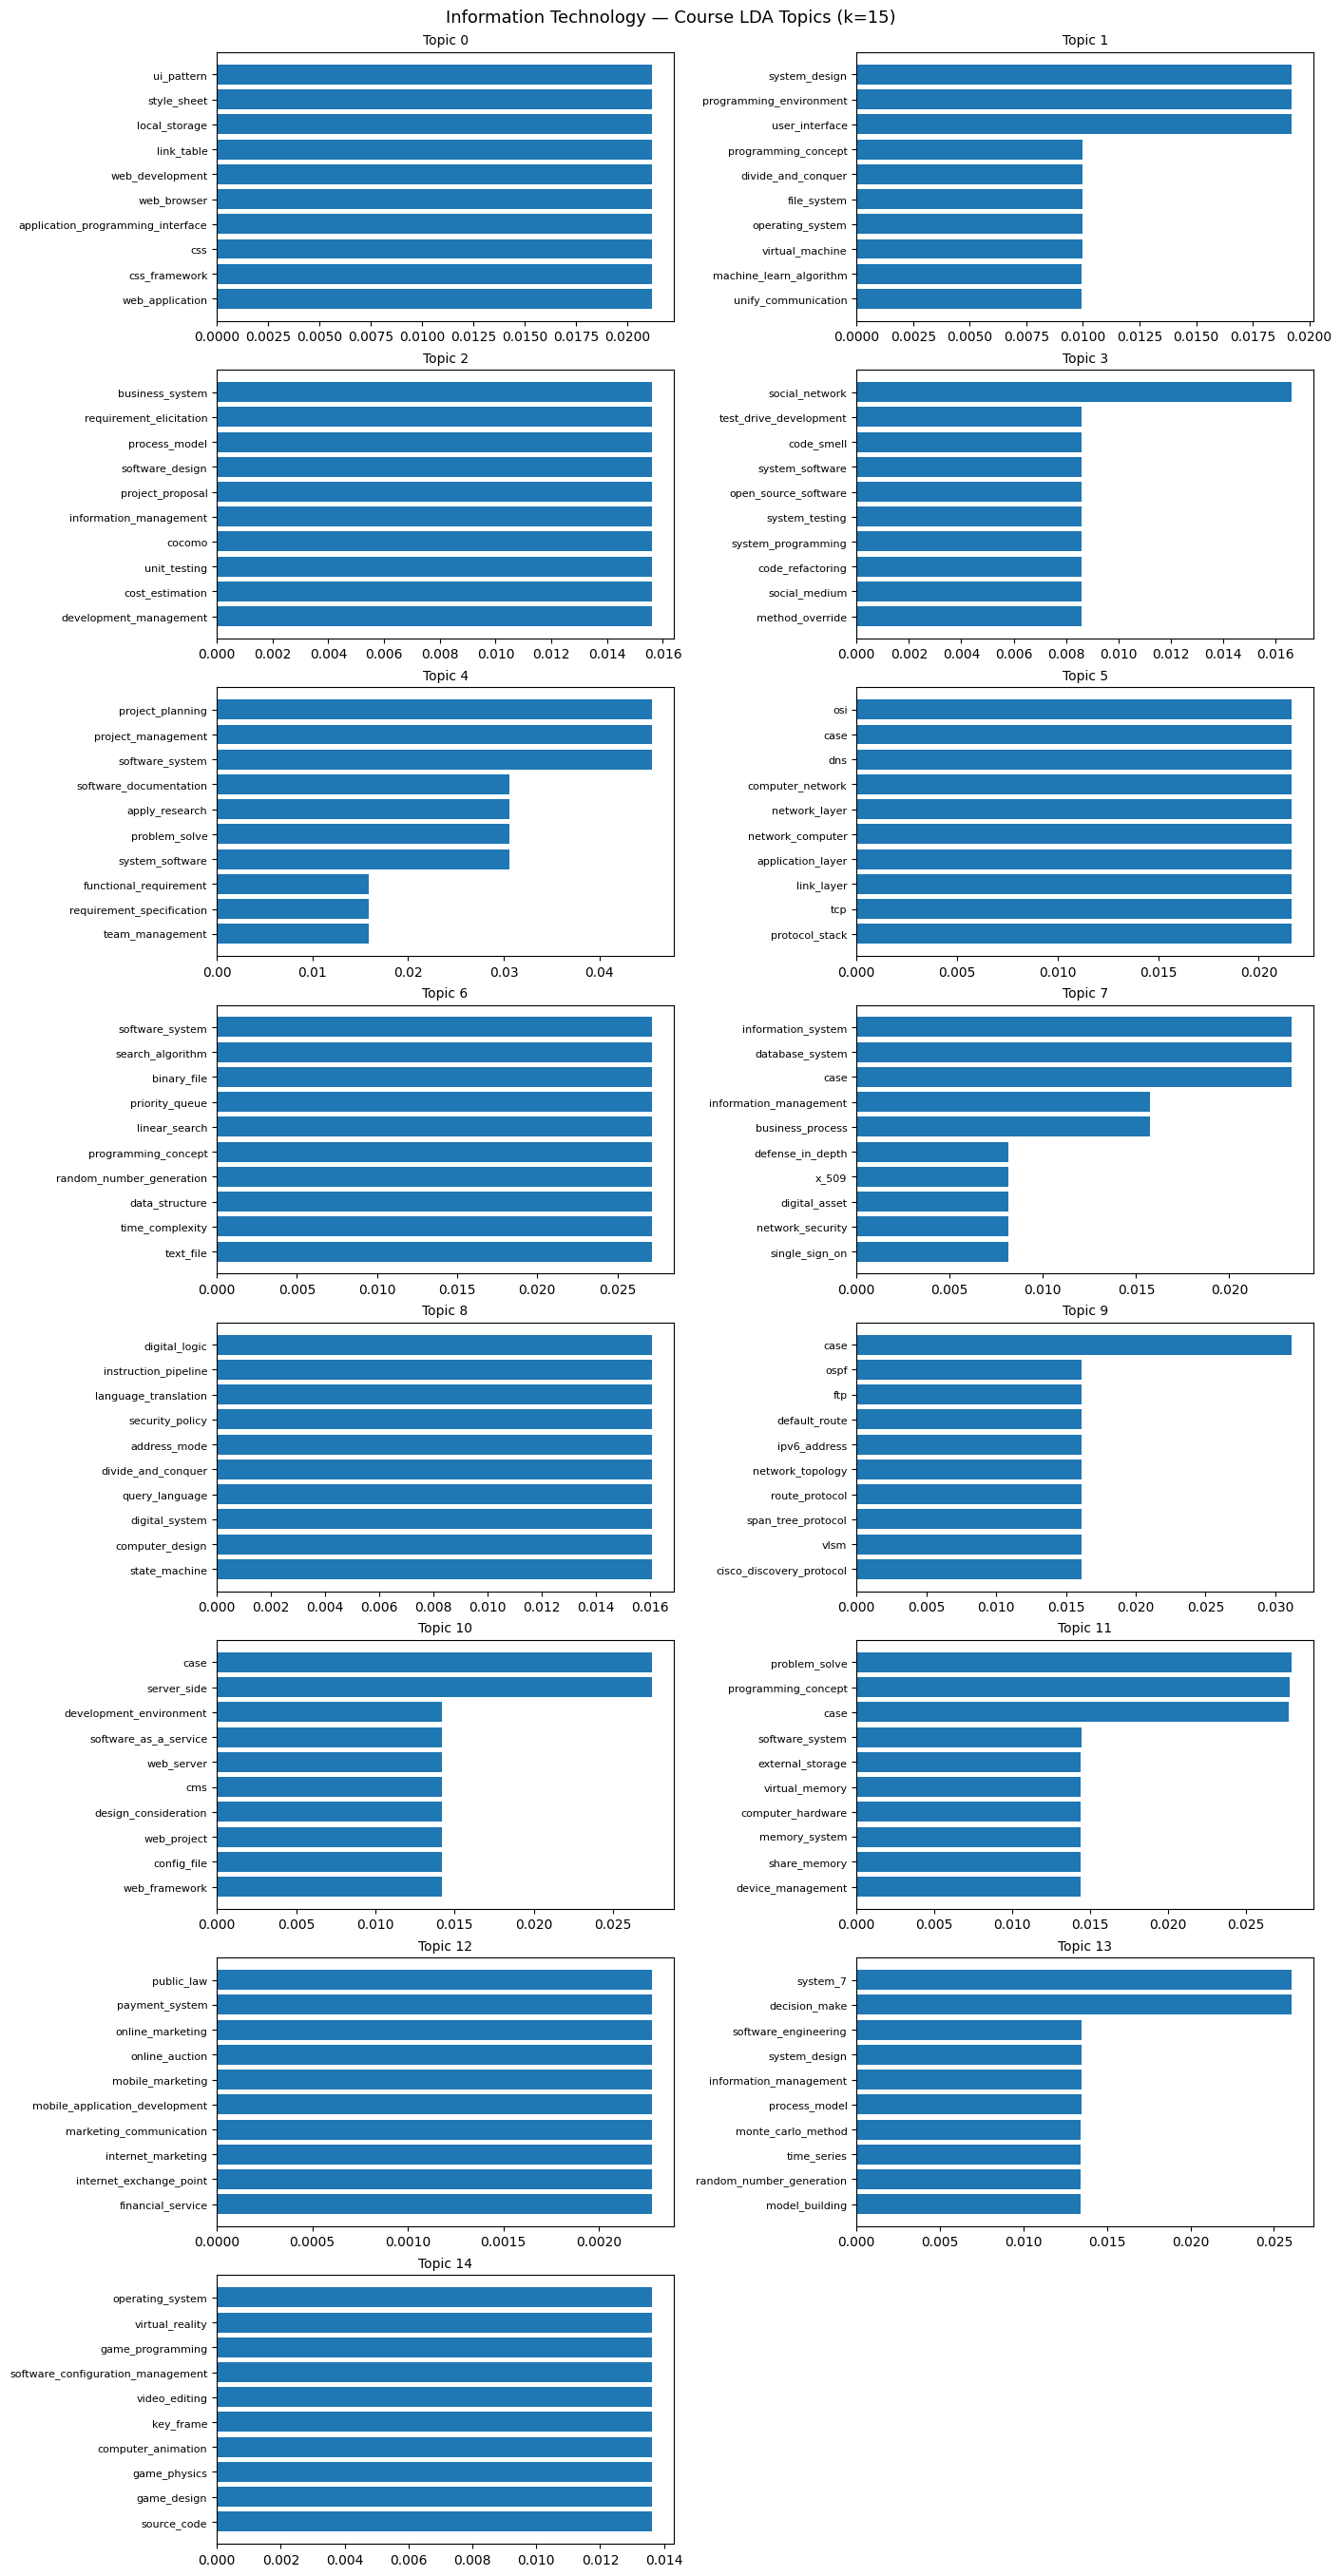

In [7]:
it_model, it_dictionary, it_corpus = train_lda(it_texts, 15, "Information Technology")
plot_top_words(it_model, 15, "Information Technology")